In [1]:
%load_ext autoreload
%autoreload 2

In [72]:
# Cell 1 — imports + reload (optional)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame, display_frame, plot_star_rois
from sim.render import RenderConfig, render, plot_render_stages
from sim.mask import Mask
from sim.frame import save_frame_fits

from sim.physics.stars import load_star_field

In [78]:
# Cell 2 — parameters + objects (6" Newtonian + ZWO ASI1600MM-ish)

# ---------- Starfield ----------
STAR_CSV = "sim/physics/starfields/field2.csv"

# ---------- Pointing ----------
RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

# ---------- Camera (ZWO ASI1600MM-ish) ----------
# ASI1600MM: 4656×3520, 3.8 µm pixels, read noise depends on gain.
cam = Camera(
    nx=4656,
    ny=3520,
    pixel_um=3.8,
    read_noise_e=1.6,        # representative mid/high-gain value; tweak as needed
    gain_e_per_adu=1.0,
    qe=0.6,                  # keep your placeholder
)

# ---------- Telescope as "Lens" (6" f/5 Newtonian-ish) ----------
# 6" = 152.4 mm aperture, f/5 => focal ~ 762 mm. We'll use 750 mm.
lens = Lens(
    focal_mm=750.0,
    f_number=5.0,
    transmission=0.85,       # rough total throughput
)

# ---------- Frame ----------
frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

# ---------- Mask (spider: Newtonian-ish) ----------
# Your model uses vane_width_mm to set spike thickness scale ~ f*λ/w
# Typical spider vane thickness might be ~0.5–1.0 mm for a 6" scope.
mask = Mask(
    kind="spider",
    angle_deg=20.0,
    n_vanes=2,

    vane_width_mm=.762,

    spike_radius_px=450,
    spike_rel_amp=0.0018,

    spike_falloff=3.0,
    spike_core_px=3.0,
    taper_frac=0.25,
)

# ---------- Render config ----------
cfg = RenderConfig(
    exposure_s=30.0,          # more “astro image” typical; tune as needed

    # background / photometry
    sky_e_per_px_s=0.0,       # leave 0 to derive from mu
    sky_mu_mag_per_arcsec2=20.5,  # slightly brighter than 21; tune
    zeropoint_e_per_s=0.0,

    # band / wavelength (used by diffraction models)
    lambda_eff_nm=550.0,
    band_nm=90.0,

    # optics
    psf_sigma_px=1.0,         # slightly sharper core for longer focal length feel; tune 0.8–1.5
    mask=mask,

    # toggles
    enable_sky=True,
    enable_stars=True,
    enable_psf=True,
    enable_jitter=False,
    enable_noise=True,

    # reproducibility
    seed=42,
)

print("Camera:", cam)
print("Lens:", lens)
print("Mask:", cfg.mask)

Camera: Camera(nx=4656, ny=3520, pixel_um=3.8, read_noise_e=1.6, gain_e_per_adu=1.0, qe=0.6)
Lens: Lens(focal_mm=750.0, f_number=5.0, transmission=0.85)
Mask: Mask(kind='spider', angle_deg=20.0, n_vanes=2, vane_width_mm=0.762, transmission=0.0, spike_radius_px=450, spike_rel_amp=0.0018, spike_falloff=3.0, spike_core_px=3.0, taper_frac=0.25, lines_per_mm=0.0, order_max=1, order_rel_amp=0.12, bitmap_path=None)


In [79]:
# Cell 3 — run simulation + quick checks

frame, res = render(frame, cfg, stars=STAR_CSV)

print("sky median (e-/px):", float(np.median(res.sky_e)))
print("stars_post_psf max (e-/px):", float(np.max(res.stars_e_post_psf)))
print("final mean/var (small patch):",
      float(np.mean(res.final_e[200:400, 200:400])),
      float(np.var(res.final_e[200:400, 200:400])))

# Optional: confirm how many catalog stars land on sensor
sf = load_star_field(STAR_CSV)
x_px, y_px = frame.radec_to_pixel(sf.ra_deg, sf.dec_deg)
on = (x_px >= 0) & (x_px < cam.nx) & (y_px >= 0) & (y_px < cam.ny)
print("catalog stars:", len(sf.ra_deg), "| on-sensor:", int(on.sum()))

sky median (e-/px): 16.714359283447266
stars_post_psf max (e-/px): 38432.45703125
final mean/var (small patch): 19.294984817504883 457.886962890625
catalog stars: 65263 | on-sensor: 115


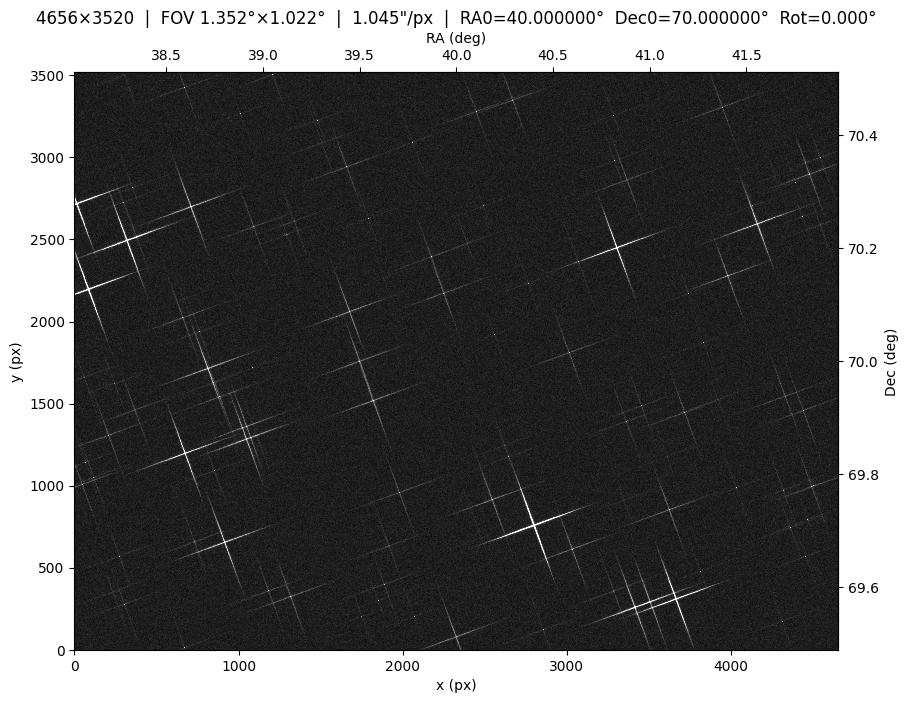

In [80]:
display_frame(frame, cmap="gray", show_ra_dec=True, stretch="linear", q_lo=0, q_hi=99.9)

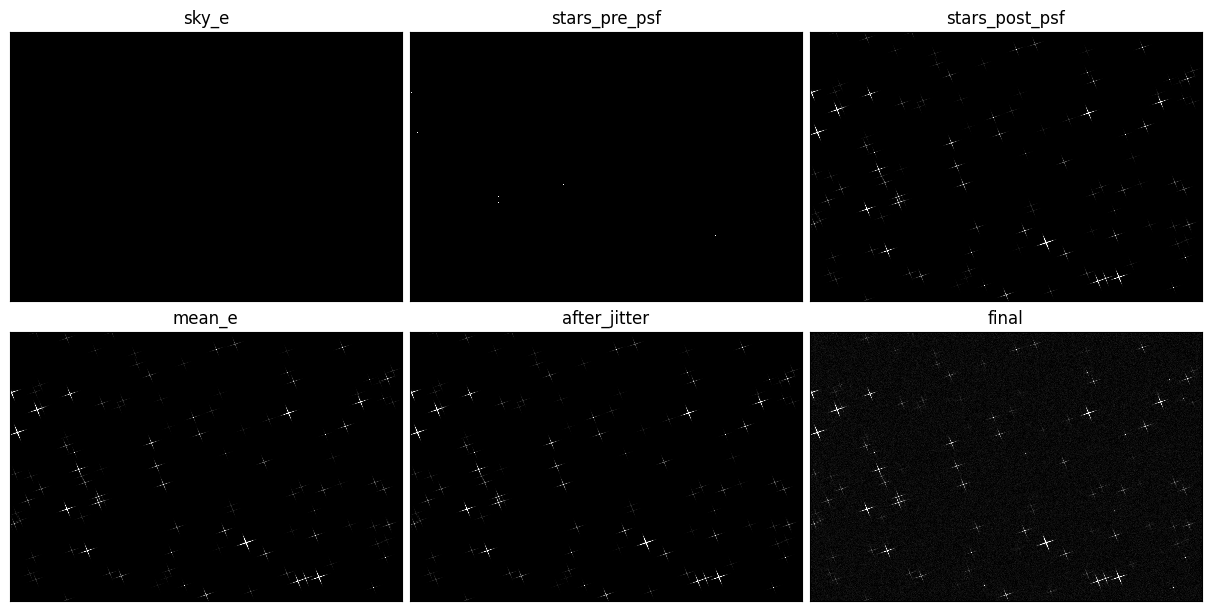

In [76]:
plot_render_stages(frame, res, cmap="gray", stretch="asinh", shared_scale=True)

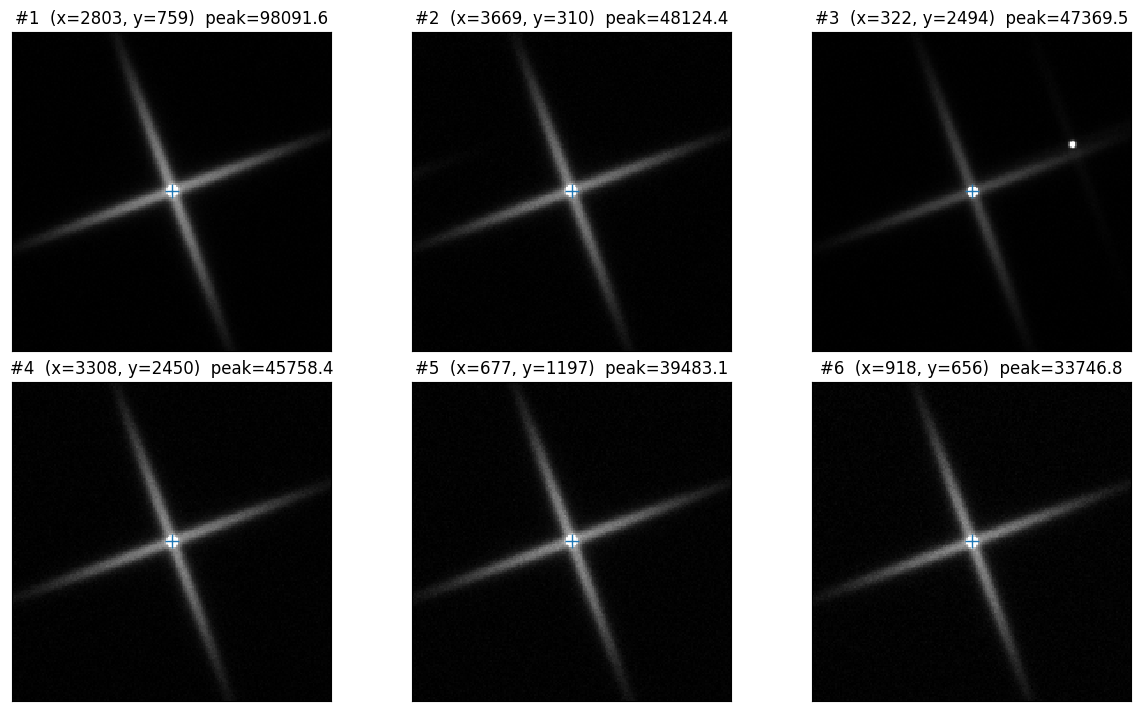

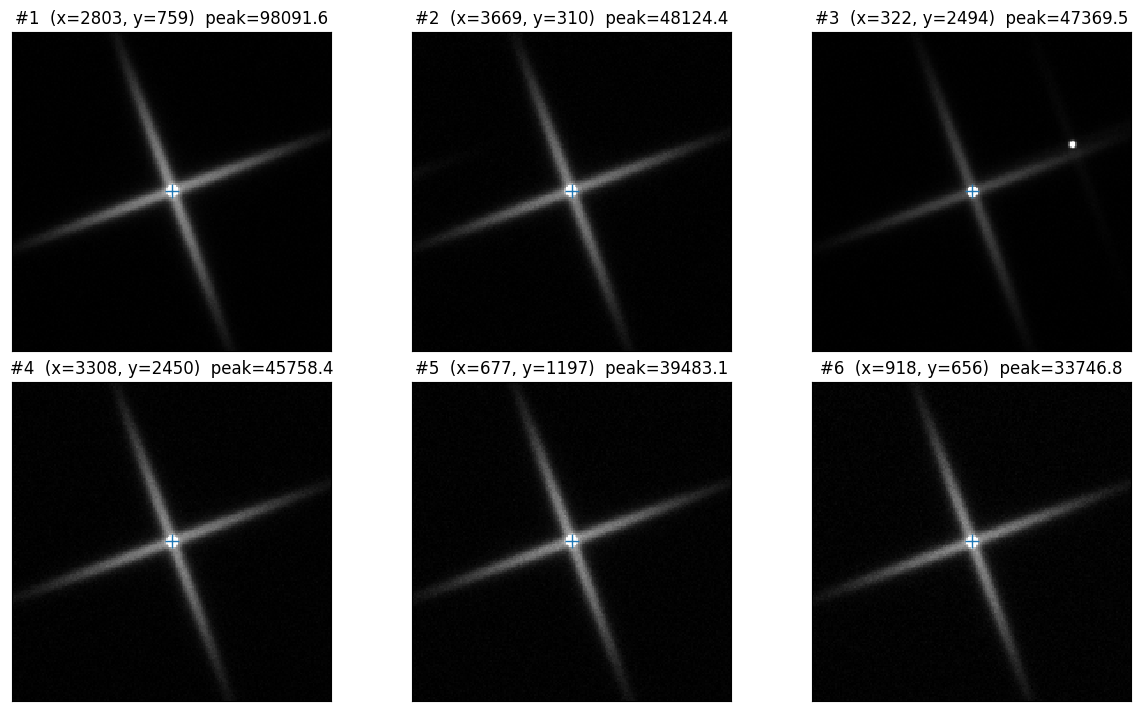

In [77]:
plot_star_rois(frame, image=res.final_e, n=6, half_size=90, min_sep_px=140, stretch="log")

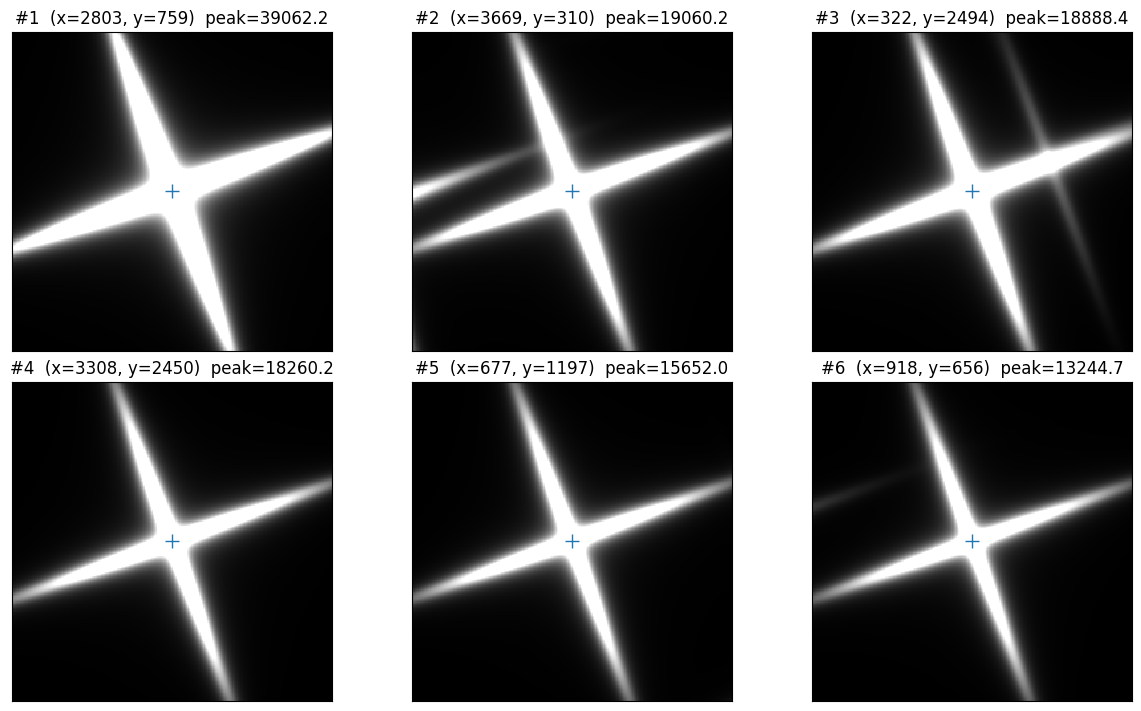

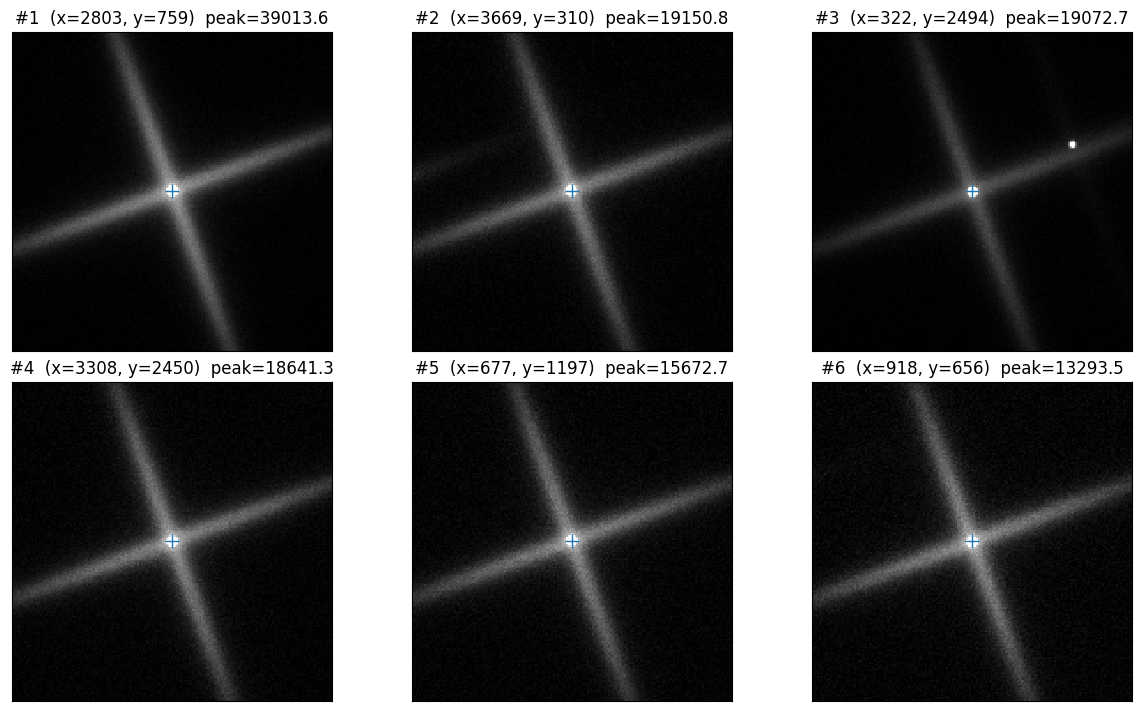

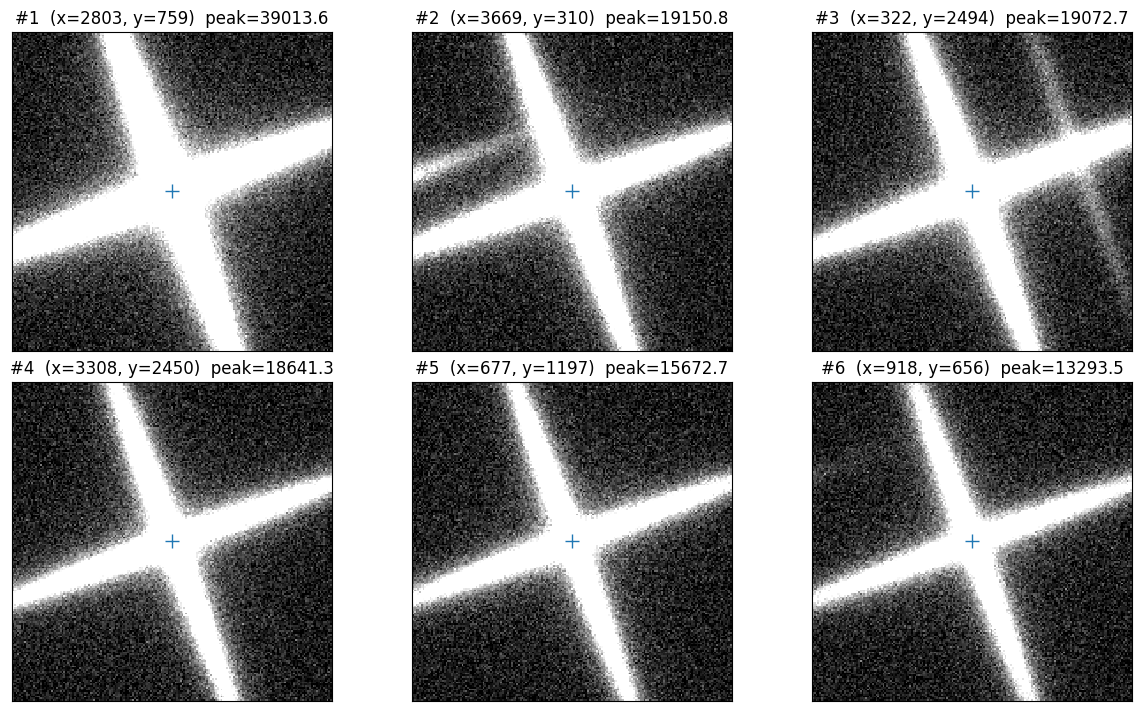

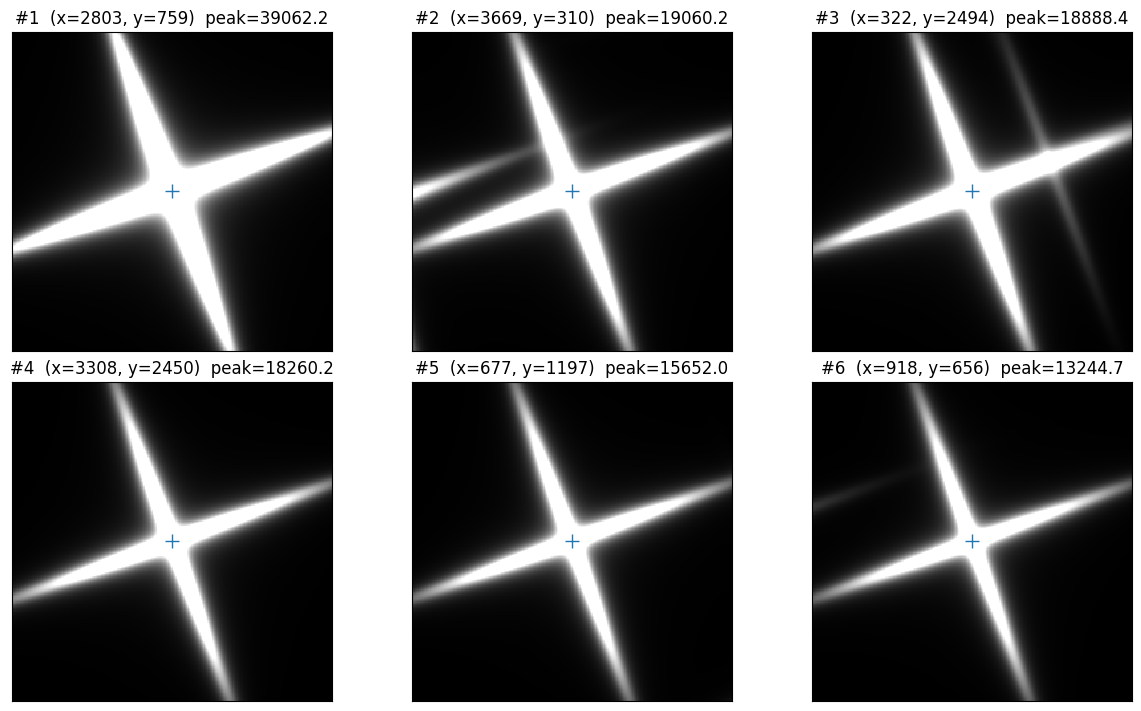

In [44]:
# ROIs with per-ROI scaling (good for “see something” debugging)
plot_star_rois(frame, image=res.final_e,
               n=6, half_size=90, min_sep_px=180,
               stretch="log", cmap="gray")

# ROIs with shared scaling (matches full-frame look much better)
plot_star_rois(frame, image=res.final_e,
               shared_scale_image=res.final_e,
               shared_q_lo=20, shared_q_hi=99.5,
               n=6, half_size=90, min_sep_px=180,
               stretch="log", cmap="gray")

# If you want “spikes truth” without noise/sky confusing things:
plot_star_rois(frame, image=res.stars_e_post_psf,
               shared_scale_image=res.stars_e_post_psf,
               shared_q_lo=10, shared_q_hi=99.7,
               n=6, half_size=120, min_sep_px=240,
               stretch="asinh", cmap="gray")

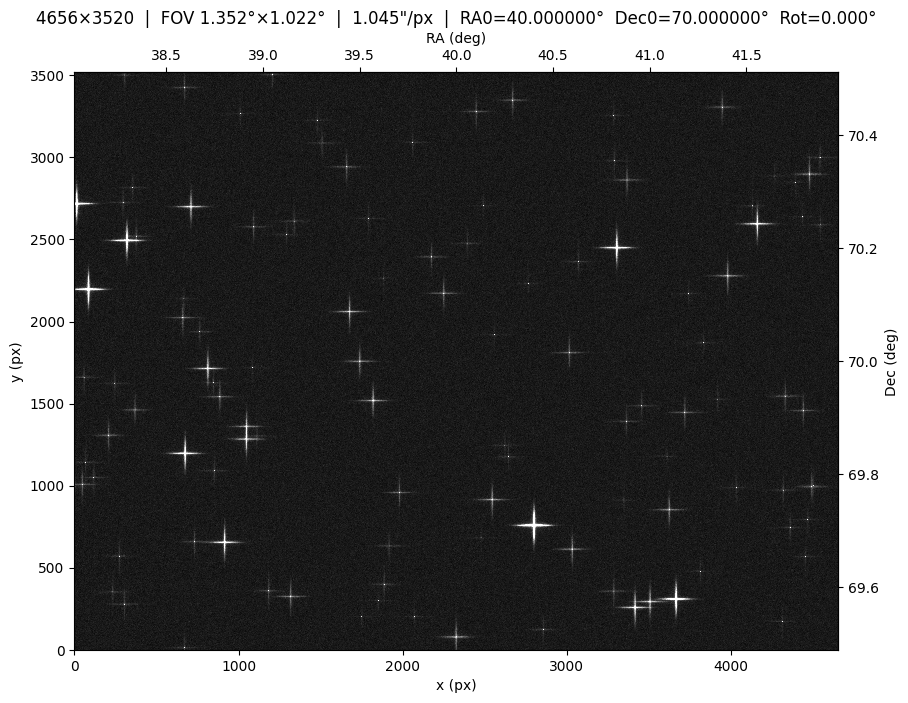

In [59]:
display_frame(frame, stretch="linear", q_lo=0, q_hi=99.9)

In [56]:
out = save_frame_fits(
    "out/newt_asi1600_final_e.fits",
    frame,
    cfg=cfg,
    res=res,
    stage="final_e",
    stars_csv=STAR_CSV,
    overwrite=True,
)
print("Wrote:", out)

Wrote: out\newt_asi1600_final_e.fits


kernel shape: (1026, 1026)
kernel sum: 1.0


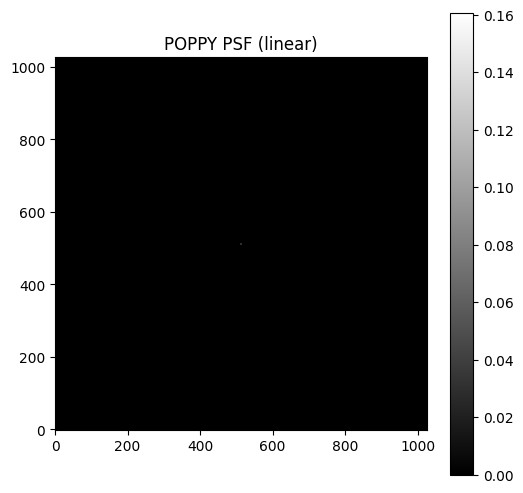

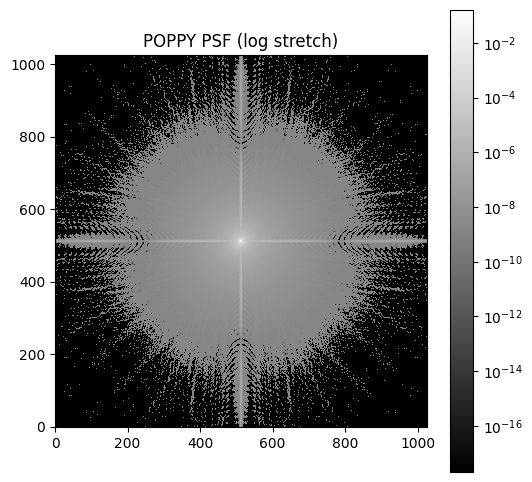

In [86]:
# Cell 1 — test POPPY kernel alone

from sim.physics.masks import kernel_for_mask
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

mask = Mask(
    kind="poppy",
    aperture_diam_mm=203.2,
    obstruction_frac=0.30,
    vane_width_mm=0.76,
    n_vanes=4,
    angle_deg=0.0,
    psf_size_px=513,
)

cfg_poppy = replace(cfg, mask=mask)

k = kernel_for_mask(frame, cfg, sigma_px=0.0, mask=mask)

print("kernel shape:", k.shape)
print("kernel sum:", np.sum(k))

plt.figure(figsize=(6,6))
plt.imshow(k, origin="lower", norm=None, cmap="gray")
plt.title("POPPY PSF (linear)")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(k, origin="lower", norm=plt.matplotlib.colors.LogNorm(), cmap="gray")
plt.title("POPPY PSF (log stretch)")
plt.colorbar()
plt.show()

In [85]:
from dataclasses import replace
from sim.mask import Mask
from sim.physics.masks import kernel_for_mask

mask = Mask(kind="poppy", aperture_diam_mm=203.2, obstruction_frac=0.30,
            vane_width_mm=0.76, n_vanes=4, angle_deg=0.0, psf_size_px=513)

cfg_poppy = replace(cfg, mask=mask)

k = kernel_for_mask(frame, cfg_poppy, sigma_px=1.2, mask=mask)  # sigma_px now actually used
print(k.shape, k.sum())

(1026, 1026) 1.0
